# 00_로컬 환경설정

In [12]:
# 라이브러리 호출
import re 
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

from helper import comenv
cfg = comenv.setup(
    seed=42,
    cpu_ratio=0.6,
    tokenizers_parallel=True,
    float32_precision="high",
    tf32=True,
    cudnn_benchmark=True,
    suppress_warnings=True,
    verbose=True,
    force_utf8=True,
    pandas_display=True,
    pd_max_columns=50,
    pd_max_rows=100,
    pd_max_colwidth=80,
    matplotlib_backend="auto",
    debug_cuda=False,
)

Platform             : Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.35
Working directory    : /d/git/01_mdls_ds8_open/10_rs/260409_프로젝트
Python version       : 3.10.14
Python executable    : /opt/conda/bin/python
Python prefix        : /opt/conda
site-packages        : ['/opt/conda/lib/python3.10/site-packages']
Encoding (stdout)    : UTF-8
----------------------------------------------------------------------
PyTorch              : 2.3.1
CUDA available       : True
Device               : cuda
Random Seed          : 42
CPU count            : 20
CPU threads (used)   : 12  (ratio=0.6)
Korean font          : NanumGothic
----------------------------------------------------------------------
GPU name             : NVIDIA GeForce RTX 5060 Ti
GPU count            : 1
GPU memory (total)   : 15.93 GB
GPU memory (free)    : 14.80 GB
TF32                 : True
cuDNN benchmark      : True
cuDNN deterministic  : True
FP32 precision       : high
CUDA (torch built)   : 12.1
CUDA (system 

# 01_데이터 불러오기 및 살펴보기

In [40]:
# README.txt에 나와있는 컬럼 정보를 지정
user_colums = ['user_id', 'gender', 'age', 'occupation', 'zip']
rating_columns = ['user_id', 'movie_id', 'rating', 'timestamp']
movie_columns = ['movie_id', 'title', 'genres']

# data 경로 설정 
data_path = './data'

# 데이터 불러오기 
users = pd.read_csv(f'{data_path}/users.dat', sep='::', header=None, names=user_colums, engine='python')
ratings = pd.read_csv(f'{data_path}/ratings.dat', sep='::', header=None, names=rating_columns, engine='python')
movies = pd.read_csv(f'{data_path}/movies.dat', sep='::', header=None, names=movie_columns, engine='python', encoding='latin-1')

1. 데이터 users: user 정보
- 사용자 정보는 user_id, gender, age, occupation, zip 정보로 구성되어 있습니다.
    - user_id: 1부터 6040으로, 익명의 정보로 되어 있음
    - gender: M or F
    - age: 18세 이하는 1, 18 ~ 24세는 18, 25 ~ 34는 25 등과 같이 구성되어 있음
    - occupation: 2는 artist, 8은 farmer 등으로 숫자값으로 매핑되어 있음
- 위와 같이 데이터가 저장되어 있습니다.

In [16]:
print(users.shape)
users.head()

(6040, 5)


,user_id,gender,age,occupation,zip
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


2. 데이터 ratings: rating 정보
- 사용자의 평점이 담겨 있는 데이터입니다. 아래와 같이 데이터가 저장되어 있습니다.
    - user_id, movie_id, rating, timestamp 컬럼으로 데이터 저장
    - user_id: 1부터 6040으로, 익명의 정보로 되어 있음
    - movie_id: 1부터 3952로, 익명의 정보로 되어 있음
    - rating: 5점 평점
    - timestamp: Unix timestamp로 되어 있음.
- Unix timestamp란
    - 1970년 1월 1일 00:00:00 UTC 이후 경과한 '초' 수를 말합니다. 우리가 흔히 알고 있는 연-월-일로 변환이 필요합니다.

In [17]:
print(ratings.shape)
ratings.head()

(1000209, 4)


,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


# 02_데이터 분석

## 02-1_영화 데이터(movies)

In [18]:
# 이 정규표현식은 '괄호 안에 있는 숫자4개만 뽑아주세요.'라는 의미입니다. 
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)')

In [19]:
movies.head()

,movie_id,title,genres,year
0,1,Toy Story (1995),Animation|Children's|Comedy,1995
1,2,Jumanji (1995),Adventure|Children's|Fantasy,1995
2,3,Grumpier Old Men (1995),Comedy|Romance,1995
3,4,Waiting to Exhale (1995),Comedy|Drama,1995
4,5,Father of the Bride Part II (1995),Comedy,1995


In [20]:
movies['genres_split'] = movies['genres'].apply(lambda x: x.split('|'))
movies_exploded = movies.explode('genres_split')
movies_exploded.head(10)

,movie_id,title,genres,year,genres_split
0,1,Toy Story (1995),Animation|Children's|Comedy,1995,Animation
0,1,Toy Story (1995),Animation|Children's|Comedy,1995,Children's
0,1,Toy Story (1995),Animation|Children's|Comedy,1995,Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy,1995,Adventure
1,2,Jumanji (1995),Adventure|Children's|Fantasy,1995,Children's
1,2,Jumanji (1995),Adventure|Children's|Fantasy,1995,Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance,1995,Comedy
2,3,Grumpier Old Men (1995),Comedy|Romance,1995,Romance
3,4,Waiting to Exhale (1995),Comedy|Drama,1995,Comedy
3,4,Waiting to Exhale (1995),Comedy|Drama,1995,Drama


In [21]:
#  장르별 영화 개수 plotly 버전(로컬 환경 또는 클라우드 노트북 환경에서 실행시켜 주세요!)
px.histogram(movies_exploded, x='genres_split', height=450, title='장르별 영화 수').update_xaxes(categoryorder="total descending")

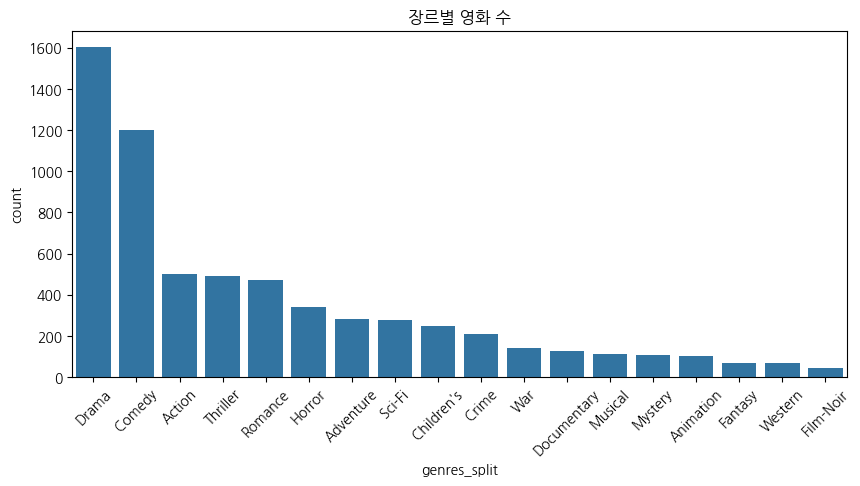

In [22]:
#  장르별 영화 개수 seaborn 버전
sns.countplot(x='genres_split', data=movies_exploded, order = movies_exploded['genres_split'].value_counts().index)

plt.gcf().set_size_inches(10, 4.5)
plt.title('장르별 영화 수')
plt.xticks(rotation=45)
plt.show()

In [23]:
# 연도별 영화 개수 plotly 버전 
movie_count_by_year = px.histogram(movies, x='year', height=450, title='연도별 영화 수').update_xaxes(categoryorder="total descending")
movie_count_by_year

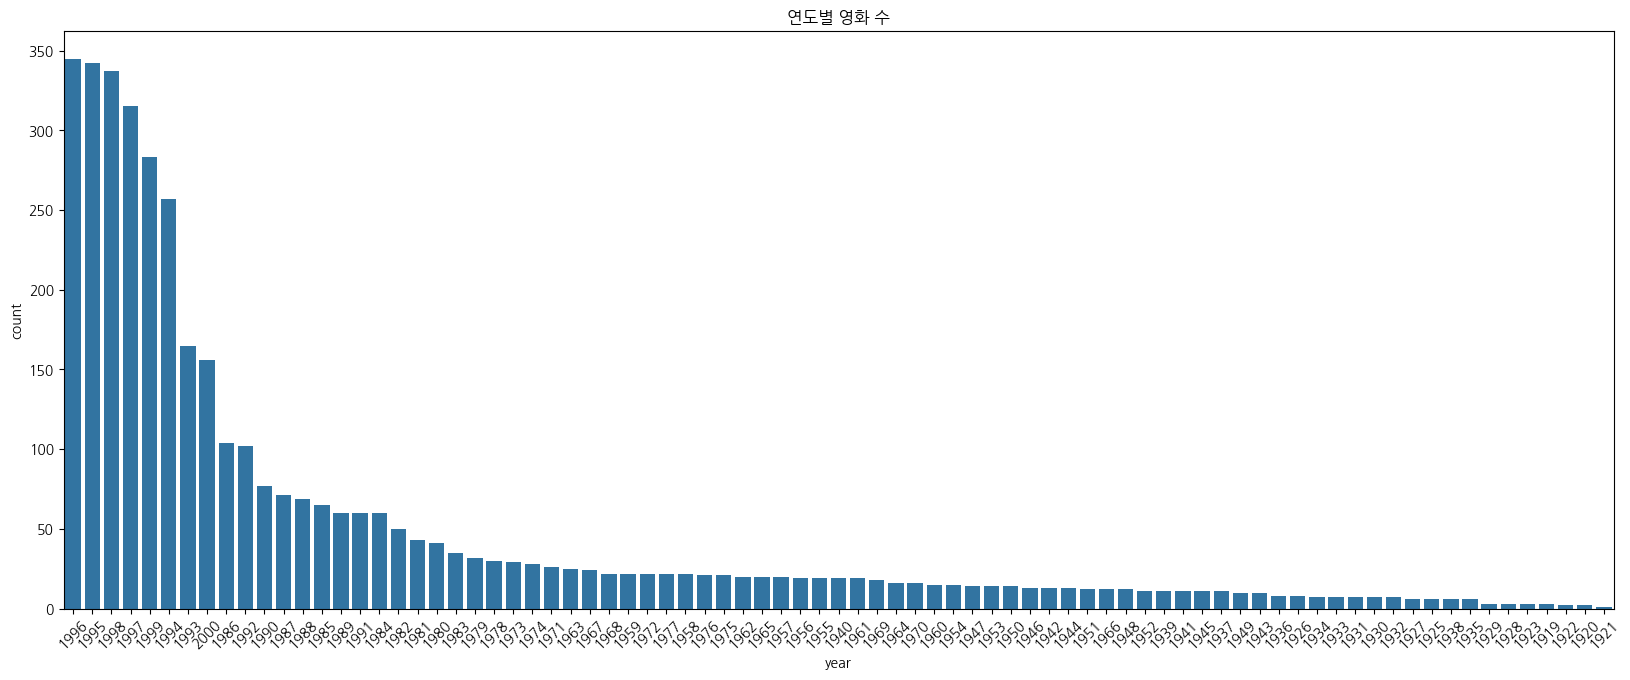

In [24]:
# 연도별 영화 개수 seaborn 버전
year_counts = movies['year'].value_counts().reset_index()
year_counts.columns = ['year', 'count']

year_counts = year_counts.sort_values('count', ascending=False)

sns.barplot(x='year', y='count', data=year_counts)

plt.gcf().set_size_inches(20, 7.5)
plt.title('연도별 영화 수')
plt.xticks(rotation=45)
plt.show()

## 02-2_평점 데이터(ratings)

In [25]:
mv_rating_agg = pd.DataFrame(ratings.groupby('movie_id')['rating'].mean())
mv_rating_agg['num_of_ratings'] = pd.DataFrame(ratings.groupby('movie_id')['rating'].count())
mv_rating_agg = mv_rating_agg.reset_index()
mv_rating_agg.columns = ['movie_id', 'avg_rating', 'num_of_ratings']
mv_rating_agg

,movie_id,avg_rating,num_of_ratings
0,1,4.1468,2077
1,2,3.2011,701
2,3,3.0167,478
3,4,2.7294,170
4,5,3.0068,296
...,...,...,...
3701,3948,3.6357,862
3702,3949,4.1151,304
3703,3950,3.6667,54
3704,3951,3.9000,40


In [26]:
# 평점 분포 plotly 버전
px.histogram(mv_rating_agg, x='avg_rating', height=450, title='평점 분포')

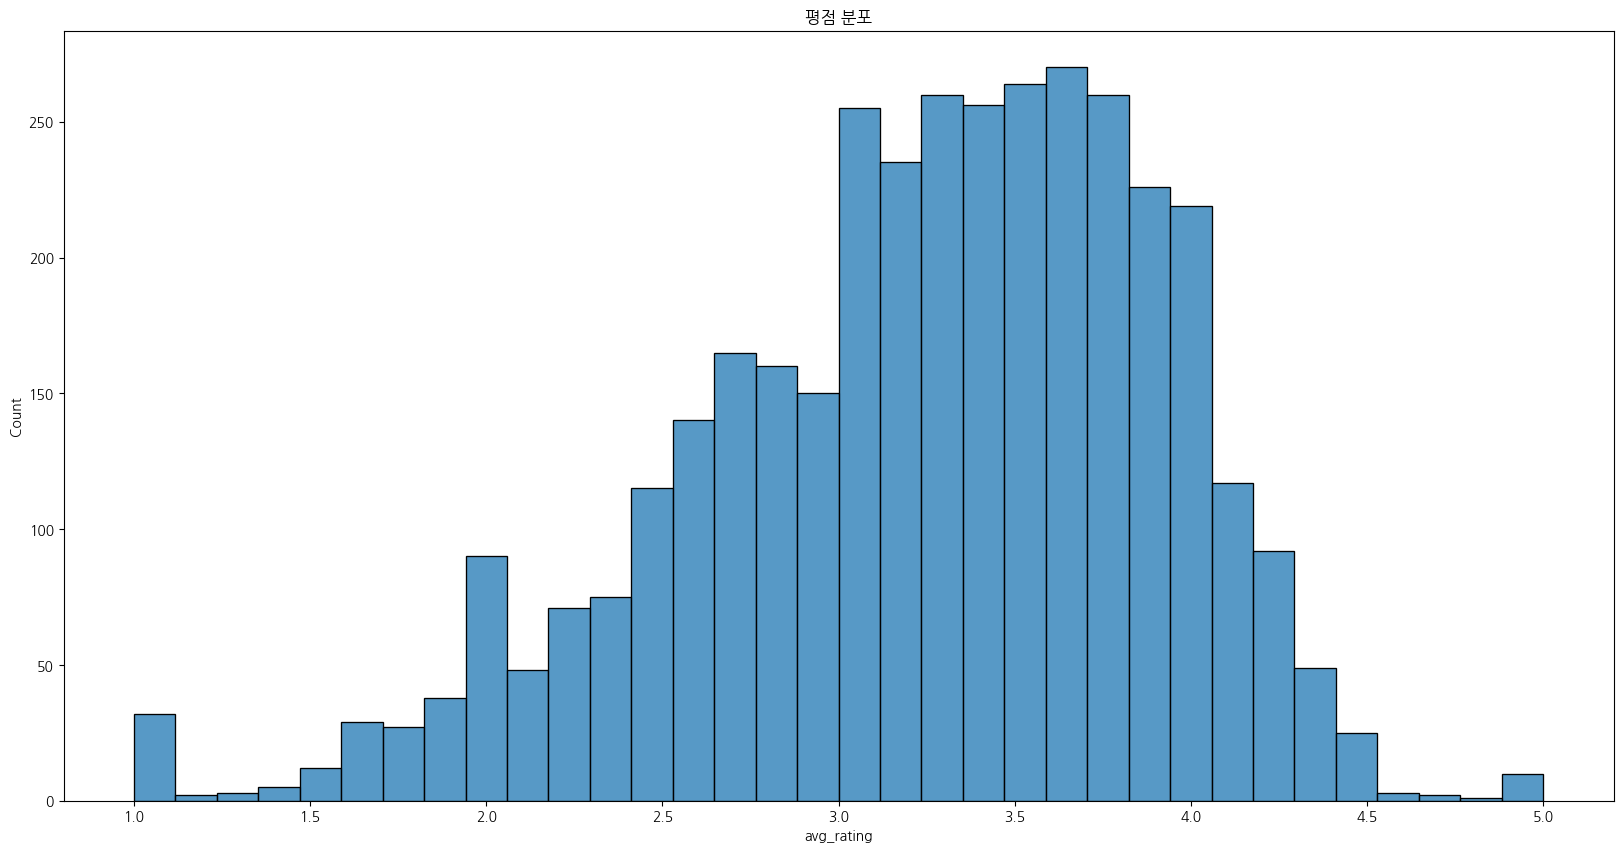

In [27]:
# 평점 분포 seaborn 버전 
sns.histplot(mv_rating_agg['avg_rating'], kde=False)
plt.gcf().set_size_inches(20, 10)
plt.title('평점 분포')
plt.show()

## 02-3_장르별 평점 분포

In [28]:
movies_exploded.head()

,movie_id,title,genres,year,genres_split
0,1,Toy Story (1995),Animation|Children's|Comedy,1995,Animation
0,1,Toy Story (1995),Animation|Children's|Comedy,1995,Children's
0,1,Toy Story (1995),Animation|Children's|Comedy,1995,Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy,1995,Adventure
1,2,Jumanji (1995),Adventure|Children's|Fantasy,1995,Children's


In [29]:
# 장르별 평점 분포를 파악하기 위해 아래와 같은 순서로 데이터를 만들어 봅시다.
# 영화 평점 데이터와 영화 데이터를 합쳐준다.
# genre_split를 기준으로 groupby한다.
# groupby할 때 rating을 기준으로 평균(mean)과 개수(count)를 뽑아낸다.
# rating과 mean을 기준으로 정렬한다.

rating_by_genre_df = pd.merge(ratings[['movie_id', 'rating']] ,
                              movies_exploded[['movie_id', 'genres_split']] ,
                              on='movie_id').groupby('genres_split').agg({'rating': ['mean', 'count']}).sort_values(('rating', 'mean')).reset_index()
rating_by_genre_df

genres_split rating        
                  mean   count
0        Horror 3.2150   76386
1    Children's 3.4220   72186
2       Fantasy 3.4474   36301
3        Sci-Fi 3.4665  157294
4     Adventure 3.4773  133953
5        Action 3.4912  257457
6        Comedy 3.5221  356580
7      Thriller 3.5705  189680
8       Romance 3.6075  147523
9       Western 3.6378   20683
10      Musical 3.6655   41533
11      Mystery 3.6681   40178
12    Animation 3.6849   43293
13        Crime 3.7087   79541
14        Drama 3.7663  354529
15          War 3.8933   68527
16  Documentary 3.9331    7910
17    Film-Noir 4.0752   18261

In [30]:
# 출력된 데이터 프레임을 보니 컬럼이 이상합니다. 
# 컬럼이 한 줄로 출력되어야 할 것 같은데, 두 줄로 되어 있습니다. 컬럼을 확인해 봅시다.
rating_by_genre_df.columns


MultiIndex([('genres_split',      ''),
            (      'rating',  'mean'),
            (      'rating', 'count')],
           )

In [32]:
# 출력된 것을 확인해보니까 MultiIndex라는 것으로 되어 있습니다.
# 평소에 우리가 보는 데이터프레임의 인덱스는 하나로만 구성되어 있을텐데요, 
# 위에서 수행했던 과정에서 '평점의 평균'과 '평점의 개수'를 동시에 구하다보니 
# '평점(rating)'이라는 값이 겹치게 되면서 데이터프레임의 인덱스가 2개가 된 것이죠.
# 그럼 우리에게 익숙한 형태, 즉 데이터프레임의 인덱스를 1개로 바꿔주면 좋겠죠?
for col in rating_by_genre_df.columns.values:
    if col[0] == 'rating':
        print('_'.join(col).strip())
    else:
        print(col[0])

# 위 과정은 col[0]의 값이 rating이면 _ 를 기준으로 데이터를 묶어달라는 의미를 가집니다.

genres_split
rating_mean
rating_count


In [33]:
rating_by_genre_df.columns = ['_'.join(col).strip() if col[1] != '' else col[0] for col in rating_by_genre_df.columns.values]    
rating_by_genre_df

,genres_split,rating_mean,rating_count
0,Horror,3.2150,76386
1,Children's,3.4220,72186
2,Fantasy,3.4474,36301
3,Sci-Fi,3.4665,157294
4,Adventure,3.4773,133953
5,Action,3.4912,257457
6,Comedy,3.5221,356580
7,Thriller,3.5705,189680
8,Romance,3.6075,147523
9,Western,3.6378,20683


In [34]:
# 장르별 평점 plotly 버전
px.bar(rating_by_genre_df, x='genres_split', y='rating_mean', height=350, title='장르별 평점').update_xaxes(categoryorder="total descending")

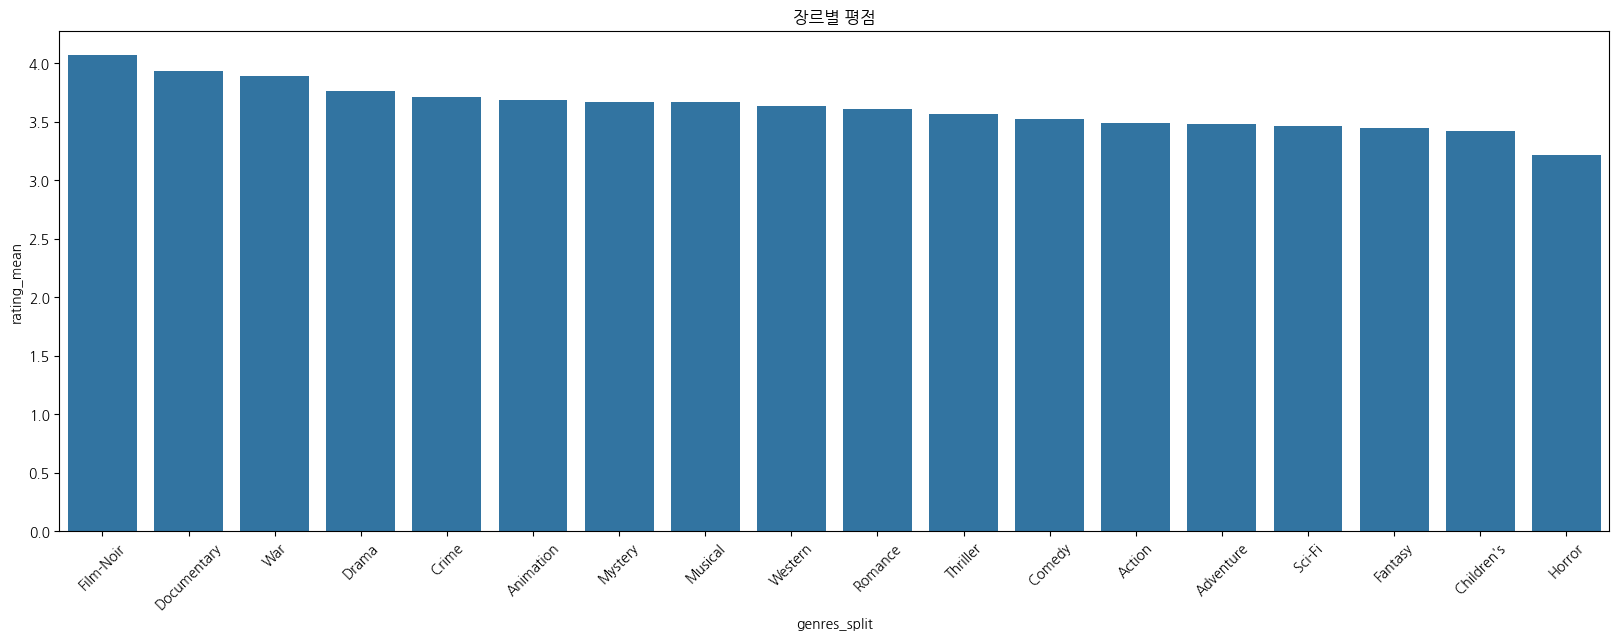

In [35]:
# 장르별 평점 seaborn 버전
rating_by_genre_df_sorted_by_mean = rating_by_genre_df.sort_values('rating_mean', ascending=False)

plt.figure(figsize=(20, 6.5))
sns.barplot(x='genres_split', y='rating_mean', data=rating_by_genre_df_sorted_by_mean)
plt.title('장르별 평점')
plt.xticks(rotation=45)
plt.show()

In [36]:
# 모든 장르가 거의 비슷한 평점을 가지고 있는 것 같네요. 다만 호러물은 다른 장르에 비해 낮은 평점을 가지고 있습니다.
# 의외로 다큐멘터리가 높은 평점을 가지고 있습니다.
# 과연 다큐멘터리 평점이 신뢰할 수 있는 값일까요?
# 좀 더 살펴보기 위해 장르별로 평가 개수를 확인해 봅시다.

# plotly 버전
px.bar(rating_by_genre_df, x='genres_split', y='rating_count', height=350, title='장르별 평가 개수').update_xaxes(categoryorder="total descending")

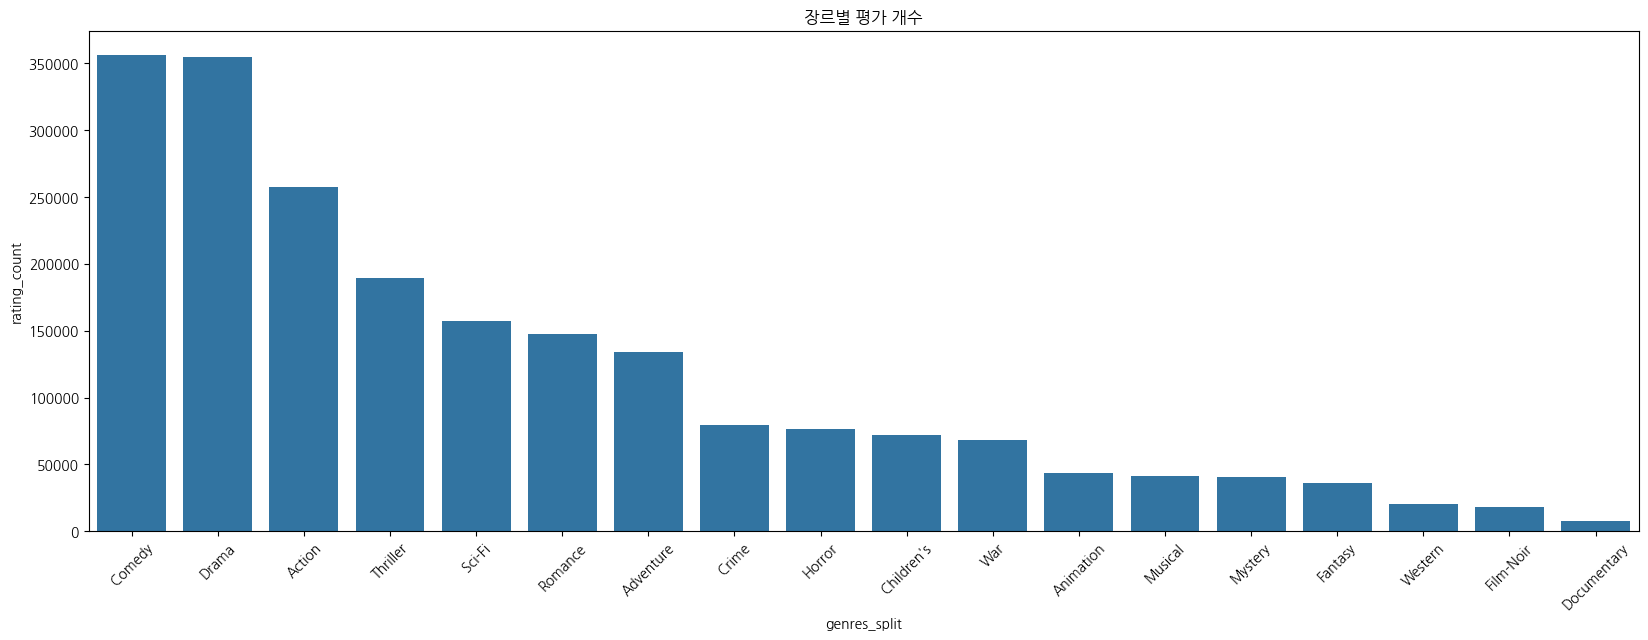

In [37]:
# seaborn 버전
rating_by_genre_df_sorted_by_count = rating_by_genre_df.sort_values('rating_count', ascending=False)

plt.figure(figsize=(20, 6.5))
sns.barplot(x='genres_split', y='rating_count', data=rating_by_genre_df_sorted_by_count)
plt.title('장르별 평가 개수')
plt.xticks(rotation=45)
plt.show()


# 높은 평점을 가지고 있던 다큐멘터리의 평가 개수가 몇 개 없습니다. 어쩌면 편항되어 있는 데이터일 수도 있겠네요. 
# 그리고 어쩌면, 다큐멘터리 영화를 본 사용자는 확실한 취향이 있을 수 있겠어요!

## 02-3_데이터 분석 마무리
- 간단하게 MovieLens1M 데이터를 살펴보았습니다. 
- 복잡한 데이터가 아니니까 어느 정도는 'MovieLens1M 데이터는 이런 데이터구나'라는 감을 잡으셨을 것 같습니다.
- 이제부터는 실제 모델 훈련에 사용할 수 있도록 데이터를 전처리해보고 훈련용 데이터를 만들어 볼 것입니다.
- 아래는 참고용으로 제공해 드리는 코드입니다. 만약 사용자 데이터(users)와 사용자가 가지고 있는 직업(occupation)을 매핑해서 
- 데이터를 깊게 살펴보고 싶다면 사용해 보세요.

In [38]:
# Occupation
occupation_map = {
    0:"other or not specified",
    1:"academic/educator",
    2:"artist",
    3:"clerical/admin",
    4:"college/grad student",
    5:"customer service",
    6:"doctor/health care",
    7:"executive/managerial",
    8:"farmer",
    9:"homemaker",
    10:"K-12 student",
    11:"lawyer",
    12:"programmer",
    13:"retired",
    14:"sales/marketing",
    15:"scientist",
    16:"self-employed",
    17:"technician/engineer",
    18:"tradesman/craftsman",
    19:"unemployed",
    20:"writer"
}

In [39]:
users['occupation_nm'] = users['occupation'].map(occupation_map)
users.head()

,user_id,gender,age,occupation,zip,occupation_nm
0,1,F,1,10,48067,K-12 student
1,2,M,56,16,70072,self-employed
2,3,M,25,15,55117,scientist
3,4,M,45,7,02460,executive/managerial
4,5,M,25,20,55455,writer
